<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/runtime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import time
import subprocess
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Runtime

pbmc8k dataset: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k, hgmm12k, tiny_cellbender, simulation1, custom
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
scar_env_cpu = "/home/jrich/miniconda3/envs/scar"
scar_env_gpu = "/home/jrich/miniconda3/envs/scar_gpu"
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name, "runtime")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name, "runtime")
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path, filename, or url for celltypist model pkl file
    expected_cells = 8381

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
else:
    raise ValueError(f"Dataset name {dataset_name} not recognized.")

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

try:
    has_gpu = subprocess.call("nvidia-smi", stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL) == 0
except Exception as e:
    has_gpu = False

max_threads = os.cpu_count()

tool_to_runtime_dict = {}

--2025-12-30 13:41:10--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32549555 (31M) [binary/octet-stream]
Saving to: ‘/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5’

/home/jrich/Desktop 100%[===================>]  31.04M  64.8MB/s    in 0.5s    

2025-12-30 13:41:11 (64.8 MB/s) - ‘/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5’ saved [32549555/32549555]

--2025-12-30 13:41:11--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com

## System specs

In [5]:
# CPU and system specs
system = platform.system()
if system == "Darwin":  # MacOS
    !system_profiler SPHardwareDataType
elif system == "Windows":
    !Get-CimInstance Win32_Processor
elif system == "Linux":
    !lscpu
else:
    print(f"Unsupported system: {system}")

# GPU specs
try:
    !nvidia-smi
except Exception as e:
    print("nvidia-smi not found or no GPU available.")


Architecture:        x86_64
CPU op-mode(s):      32-bit, 64-bit
Byte Order:          Little Endian
CPU(s):              88
On-line CPU(s) list: 0-87
Thread(s) per core:  2
Core(s) per socket:  22
Socket(s):           2
NUMA node(s):        2
Vendor ID:           GenuineIntel
CPU family:          6
Model:               85
Model name:          Intel(R) Xeon(R) Gold 6152 CPU @ 2.10GHz
Stepping:            4
CPU MHz:             3700.000
CPU max MHz:         3700.0000
CPU min MHz:         1000.0000
BogoMIPS:            4200.00
Virtualization:      VT-x
L1d cache:           32K
L1i cache:           32K
L2 cache:            1024K
L3 cache:            30976K
NUMA node0 CPU(s):   0-21,44-65
NUMA node1 CPU(s):   22-43,66-87
Flags:               fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush dts acpi mmx fxsr sse sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm constant_tsc art arch_perfmon pebs bts rep_good nopl xtopology nonstop_tsc cpuid aperfmperf pni pclmulqdq

## Raw

In [6]:
adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

if "celltype" not in adata_raw.obs.columns:
    adata_raw = cs_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)

13:41:17 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
13:41:18 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=8381.
13:41:18 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
👉 Detailed model inf

## cellsweep

13:41:58 - INFO - Starting cellsweep denoising at 2025-12-30 13:41:58, cellsweep version 0.1.0
13:41:58 - INFO - Inferring celltype profiles.


Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/pbmc8k_cellsweep_1threads.log


13:41:59 - DEBUG - Number of parameters in the cellsweep model: 277,934 (alpha: 8,381, beta: 1, p_k: 269,552)
13:41:59 - INFO - Inferring the gene ambient profile from empty droplets.
13:41:59 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
13:41:59 - INFO - Performing Sparse EM with 1 Numba thread(s)
13:42:04 - INFO - EM Iter   1: ll=-420.939 min_alpha=0.7245 mean_alpha=0.8870 median_alpha=0.8897 max_alpha=0.9246 beta=0.030634
13:42:08 - INFO - EM Iter   2: ll=-419.452 min_alpha=0.3687 mean_alpha=0.8574 median_alpha=0.8638 max_alpha=0.9547 beta=0.030691
13:42:09 - INFO - EM Iter   3: ll=-418.529 min_alpha=0.2077 mean_alpha=0.8249 median_alpha=0.8313 max_alpha=0.9769 beta=0.030534
13:42:10 - INFO - EM Iter   4: ll=-417.925 min_alpha=0.1505 mean_alpha=0.7936 median_alpha=0.7973 max_alpha=0.9899 beta=0.030286
13:42:11 - INFO - EM Iter   5: ll=-417.516 min_alpha=0.1296 mean_alpha=0.7652 median_alpha=0.7645 max_alpha=0.9956 beta=0.0299

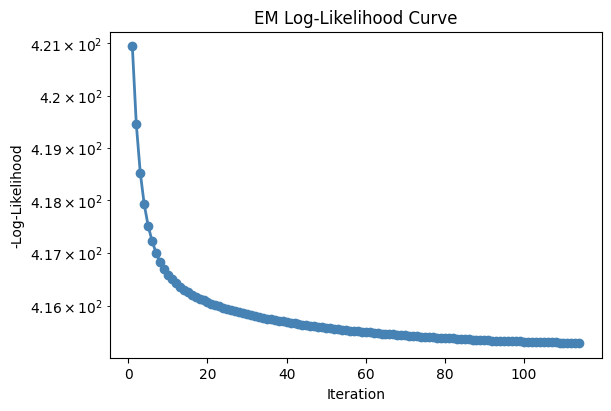

In [7]:
threads = 1

if threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

adata_path_cellsweep = os.path.join(data_dir, f"pbmc8k_cellsweep_{threads}threads.h5ad")
cellsweep_log_file = os.path.join(data_dir, f"pbmc8k_cellsweep_{threads}threads.log")

adata = adata_raw.copy()
if "celltype" not in adata.obs.columns:
    adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
start_time = time.perf_counter()
_ = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
cellsweep_runtime = time.perf_counter() - start_time
tool_to_runtime_dict[f"cellsweep_{threads}threads"] = cellsweep_runtime

cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)

13:43:39 - INFO - Starting cellsweep denoising at 2025-12-30 13:43:39, cellsweep version 0.1.0
13:43:39 - INFO - Inferring celltype profiles.


Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/cellsweep_16threads.log


13:43:39 - DEBUG - Number of parameters in the cellsweep model: 277,934 (alpha: 8,381, beta: 1, p_k: 269,552)
13:43:39 - INFO - Inferring the gene ambient profile from empty droplets.
13:43:39 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
13:43:39 - INFO - Performing Sparse EM with 16 Numba thread(s)
13:43:40 - INFO - EM Iter   1: ll=-420.939 min_alpha=0.7245 mean_alpha=0.8870 median_alpha=0.8897 max_alpha=0.9246 beta=0.030634
13:43:40 - INFO - EM Iter   2: ll=-419.452 min_alpha=0.3687 mean_alpha=0.8574 median_alpha=0.8638 max_alpha=0.9547 beta=0.030691
13:43:40 - INFO - EM Iter   3: ll=-418.529 min_alpha=0.2077 mean_alpha=0.8249 median_alpha=0.8313 max_alpha=0.9769 beta=0.030534
13:43:40 - INFO - EM Iter   4: ll=-417.925 min_alpha=0.1505 mean_alpha=0.7936 median_alpha=0.7973 max_alpha=0.9899 beta=0.030286
13:43:40 - INFO - EM Iter   5: ll=-417.516 min_alpha=0.1296 mean_alpha=0.7652 median_alpha=0.7645 max_alpha=0.9956 beta=0.029

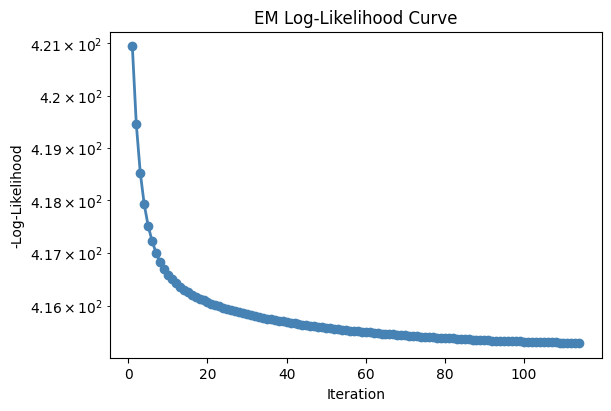

In [8]:
threads = 16

if threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")
    
adata_path_cellsweep = os.path.join(data_dir, f"cellsweep_{threads}threads.h5ad")
cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{threads}threads.log")

adata = adata_raw.copy()
if "celltype" not in adata.obs.columns:
    adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
start_time = time.perf_counter()
_ = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
cellsweep_runtime = time.perf_counter() - start_time
tool_to_runtime_dict[f"cellsweep_{threads}threads"] = cellsweep_runtime

cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)

13:10:26 - INFO - Inferring celltype profiles.


Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/runtime/cellsweep_64threads.log


13:10:26 - DEBUG - Number of parameters in the cellsweep model: 269,553 beta: 1, gamma_type: 67,048, p_k: 269,552)
13:10:30 - INFO - Inferring the gene ambient profile from empty droplets.
13:10:30 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
13:10:30 - INFO - Performing Sparse EM with 64 Numba thread(s)
13:10:35 - INFO - EM Iter   1: ll=-310098338.865 min_alpha=0.7063 mean_alpha=0.8801 median_alpha=0.8825 max_alpha=0.9282 beta=0.030473
13:10:36 - INFO - EM Iter   2: ll=-309160532.568 min_alpha=0.3575 mean_alpha=0.8491 median_alpha=0.8544 max_alpha=0.9601 beta=0.030470
13:10:38 - INFO - EM Iter   3: ll=-308485482.280 min_alpha=0.2032 mean_alpha=0.8157 median_alpha=0.8205 max_alpha=0.9814 beta=0.030263
13:10:39 - INFO - EM Iter   4: ll=-308049682.860 min_alpha=0.1480 mean_alpha=0.7842 median_alpha=0.7860 max_alpha=0.9920 beta=0.029976
13:10:40 - INFO - EM Iter   5: ll=-307757743.989 min_alpha=0.1276 mean_alpha=0.7558 median_alpha

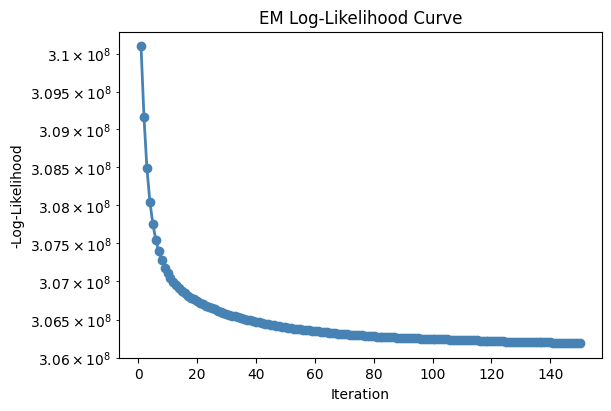

In [ ]:
# threads = 64

# if threads > max_threads:
#     SystemExit(f"Requested {threads} threads but only {max_threads} available.")
    
# adata_path_cellsweep = os.path.join(data_dir, f"cellsweep_{threads}threads.h5ad")
# cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{threads}threads.log")

# adata = adata_raw.copy()
# if "celltype" not in adata.obs.columns:
#     adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
# start_time = time.perf_counter()
# _ = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
# cellsweep_runtime = time.perf_counter() - start_time
# tool_to_runtime_dict[f"cellsweep_{threads}threads"] = cellsweep_runtime

# cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)

## CellBender (v0.3.0)

In [ ]:
use_cuda = False
threads = 1

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_cpu_1threads.h5 --epochs 150 --fpr 0.01 --model full --cpu-threads 1
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 7447dc7ef0)
cellbender:remove-background: 2025-11-23 08:05:04
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estimate

In [ ]:
use_cuda = False
threads = 16

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_cpu_16threads.h5 --epochs 150 --fpr 0.01 --model full --cpu-threads 16
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 12dd223dd0)
cellbender:remove-background: 2025-11-23 16:29:25
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estima

In [ ]:
# use_cuda = False
# threads = 64

# if use_cuda and not has_gpu:
#      SystemExit("CUDA requested but no GPU available.")
# if not use_cuda and threads > max_threads:
#     SystemExit(f"Requested {threads} threads but only {max_threads} available.")

# epochs = 150
# runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
# gpus = "--gpus all" if use_cuda else ""
# input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
# output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data")

# start_time = time.perf_counter()
# !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
#      cellbender remove-background \
#      --input {input_path} \
#      --output {output_path} \
#      --epochs {epochs} \
#      --fpr 0.01 \
#      --model full \
#      {runtime}
# cellbender_runtime = time.perf_counter() - start_time
# dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
# tool_to_runtime_dict[dict_key] = cellbender_runtime

In [ ]:
use_cuda = True
threads = None

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellsweep_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_gpu.h5 --epochs 150 --fpr 0.01 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 87dc8c41ea)
cellbender:remove-background: 2025-11-23 18:38:21
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estimated to have <= 0.1 b

## SoupX (v1.6.2)

In [ ]:
adata_soupx_obs_csv = f"{data_dir}/soupx_obs.csv"
if not os.path.exists(adata_soupx_obs_csv):
    adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
    adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

soupx_out_prefix = os.path.join(data_dir, f"soupX")

start_time = time.perf_counter()
!{docker} run --rm \
    -w /home/ruser/work \
    -v {cellsweep_dir}:{rver_docker_workspace} \
    josephrich98/cellsweep_tutorials:soupx.0.1.0 \
    Rscript {rver_docker_workspace}/scripts/run_soupx.R \
        {matrix_tar_files_dir.replace(cellsweep_dir, rver_docker_workspace)} \
        {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
        {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
        leiden
soupx_runtime = time.perf_counter() - start_time
tool_to_runtime_dict["soupx"] = soupx_runtime

Loading data from: /home/ruser/work/cellsweep/notebooks/data/pbmc8k/runtime/matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Estimating contamination fraction...
814 genes passed tf-idf cut-off and 350 soup quantile filter.  Taking the top 100.
Using 1100 independent estimates of rho.
Estimated global rho of 0.07
Adjusting counts...
Expanding counts from 18 clusters to 8381 cells.
Writing output matrices...
Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you
NULL
✅ SoupX completed successfully.


## DecontX (v1.8.0)

In [ ]:
decontx_out_prefix = os.path.join(data_dir, f"decontX")

start_time = time.perf_counter()
!{docker} run --rm \
    -w /home/ruser/work \
    -v {cellsweep_dir}:{rver_docker_workspace} \
    josephrich98/cellsweep_tutorials:decontx.0.1.0 \
    Rscript {rver_docker_workspace}/scripts/run_decontx.R \
        {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
        {filtered_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
        {sequencing_technology} \
        {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
        --dont_prepend_sample_to_barcodes
decontx_runtime = time.perf_counter() - start_time
tool_to_runtime_dict["decontx"] = decontx_runtime

📦 Starting DecontX pipeline...
Raw matrix dir:  /home/ruser/work/cellsweep/notebooks/data/pbmc8k/runtime/matrix_tar_files/raw_gene_bc_matrices/GRCh38 
Filtered matrix dir:  /home/ruser/work/cellsweep/notebooks/data/pbmc8k/runtime/matrix_tar_files/filtered_gene_bc_matrices/GRCh38 
Sequencing technology:  10XV2 
Importing filtered CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Importing raw CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Standardizing cell and gene names...
Running decontX denoising...
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Sun Nov 23 19:00:55 2025 .. Analyzing all cells
Sun Nov 23 19:00:55 2025 .... Generating UMAP and estimating cell types
Sun Nov 23 19:01:16 2025 .... Estimating contamination
Sun Nov 23 19:01:18 2025 ...... Completed iteration: 10 | converge: 0.02928
Sun Nov 23 19

## scAR (v0.7.0)

In [ ]:
%env MPLBACKEND=
use_cuda = False

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")

epochs = 150
adata_path_scar = os.path.join(data_dir, f"scar_gpu.h5ad") if use_cuda else os.path.join(data_dir, f"scar_cpu_{threads}threads.h5ad")

runtime = "--cuda" if use_cuda else ""
conda_run_flag = "-p" if "/" in scar_env_cpu else "-n"
start_time = time.perf_counter()
!conda run {conda_run_flag} {scar_env_cpu} \
     python {cellsweep_dir}/scripts/run_scar.py \
     -r {raw_tar_file_dir} \
     -f {filtered_tar_file_dir} \
     -o {adata_path_scar} \
     {runtime} \
     --epochs {epochs}
scar_runtime = time.perf_counter() - start_time
dict_key = f"scar_{'gpu' if use_cuda else 'cpu'}"
tool_to_runtime_dict[dict_key] = scar_runtime

env: MPLBACKEND=
Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...

Training:   0%|                                        | 0/150 [00:00<?, ?it/s]
                                                                               

Training: 100%|█████████████| 150/150 [20:29<00:00,  8.20s/it, Loss=4.2517e+03]
Performing inference...
Saving results...

2025-11-23 11:02:46|INFO|setup_anndata|Use all 261019 droplets.
2025-11-23 11:02:47|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-11-23 11:03:45|INFO|setup_anndata|Iteration: 1
2025-11-23 11:04:44|INFO|setup_anndata|Iteration: 2
2025-11-23 11:05:42|INFO|setup_anndata|Iteration: 3
2025-11-23 11:05:42|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-11-23 11:05:43|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-11-23 11:05:45|INFO|model|cpu will be used.
2025-11-23 11:05:45|INFO|model|Found ambient p

In [13]:
%env MPLBACKEND=
use_cuda = True

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")

epochs = 150
adata_path_scar = os.path.join(data_dir, f"scar_gpu.h5ad") if use_cuda else os.path.join(data_dir, f"scar_cpu_{threads}threads.h5ad")

runtime = "--cuda" if use_cuda else ""
conda_run_flag = "-p" if "/" in scar_env_gpu else "-n"
start_time = time.perf_counter()
!conda run {conda_run_flag} {scar_env_gpu} \
     python {cellsweep_dir}/scripts/run_scar.py \
     -r {raw_tar_file_dir} \
     -f {filtered_tar_file_dir} \
     -o {adata_path_scar} \
     {runtime} \
     --epochs {epochs}
scar_runtime = time.perf_counter() - start_time
dict_key = f"scar_{'gpu' if use_cuda else 'cpu'}"
tool_to_runtime_dict[dict_key] = scar_runtime

env: MPLBACKEND=
Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...

Training:   0%|          | 0/150 [00:00<?, ?it/s]
                                                 

Training: 100%|██████████| 150/150 [08:51<00:00,  3.54s/it, Loss=4.2425e+03]
Performing inference...
Saving results...

2025-11-24 11:33:47|INFO|setup_anndata|Use all 261019 droplets.
2025-11-24 11:33:48|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-11-24 11:34:54|INFO|setup_anndata|Iteration: 1
2025-11-24 11:36:07|INFO|setup_anndata|Iteration: 2
2025-11-24 11:37:05|INFO|setup_anndata|Iteration: 3
2025-11-24 11:37:05|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-11-24 11:37:05|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-11-24 11:37:09|INFO|model|cuda will be used.
2025-11-24 11:37:09|INFO|model|Found ambient profile in AnnData.uns['ambient_profile_all']
2025-11-24 11:37:

In [ ]:
# convert to minutes
# tool_to_runtime_minutes_dict = {'cellsweep_1threads': 1.6671664381360947, 'cellsweep_16threads': 0.20166109446824218, 'cellbender_cpu_1threads': 504.35386805809105, 'cellbender_cpu_16threads': 128.92702953227175, 'cellbender_gpu': 22.02172445510514, 'soupx': 1.6098512041382491, 'decontx': 2.1877690135035666, 'scar_cpu': 24.54572350685485, 'scar_gpu': 13.524172533024103}
tool_to_runtime_minutes_dict = {k: v / 60 for k, v in tool_to_runtime_dict.items()}
print(tool_to_runtime_minutes_dict)

{'cellsweep_1threads': 1.6671664381360947, 'cellsweep_16threads': 0.20166109446824218, 'cellbender_cpu_1threads': 504.35386805809105, 'cellbender_cpu_16threads': 128.92702953227175, 'cellbender_gpu': 22.02172445510514, 'soupx': 1.6098512041382491, 'decontx': 2.1877690135035666, 'scar_cpu': 24.54572350685485, 'scar_gpu': 13.524172533024103}


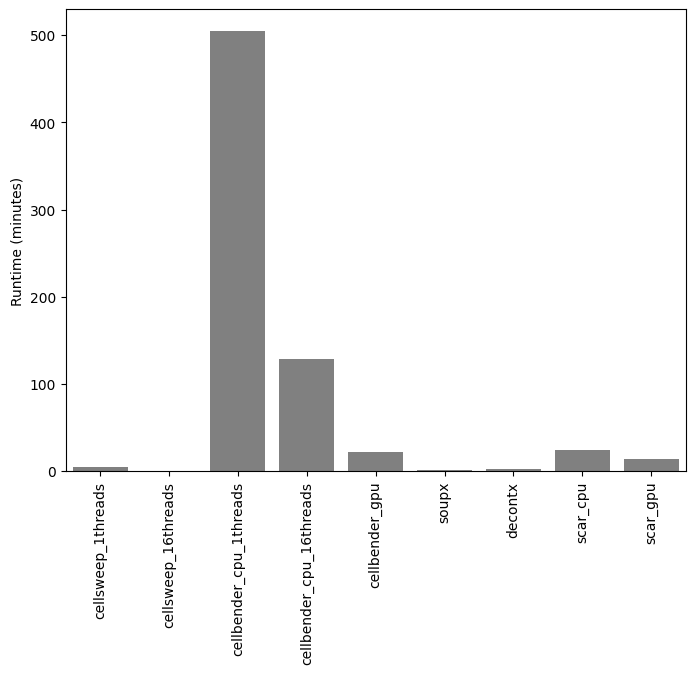

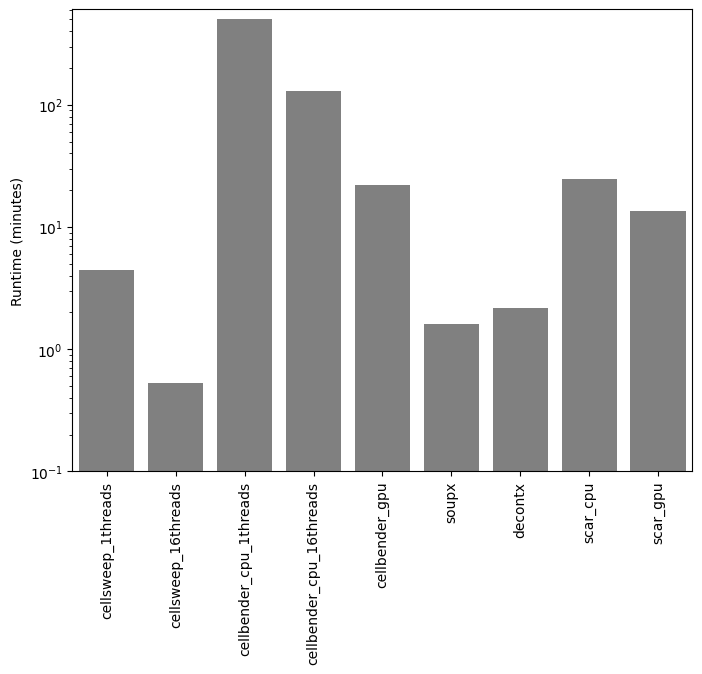

In [14]:
def plot_runtime_comparison(tool_to_runtime_minutes_dict, log=False, out_path=None):
    plt.figure(figsize=(8,6))
    sns.barplot(x=list(tool_to_runtime_minutes_dict.keys()), y=list(tool_to_runtime_minutes_dict.values()), color="gray")
    plt.xticks(rotation=90)
    plt.ylabel("Runtime (minutes)")
    if log:
        plt.ylim(0.1, max(tool_to_runtime_minutes_dict.values()) * 1.2)
        plt.yscale("log")
    if out_path:
        plt.savefig(out_path)
    plt.show()

plot_runtime_comparison(tool_to_runtime_minutes_dict, out_path=os.path.join(out_dir, "runtime_comparison.png"))
plot_runtime_comparison(tool_to_runtime_minutes_dict, log=True, out_path=os.path.join(out_dir, "runtime_comparison_log.png"))